### Imports and Settings

In [1]:
import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

import torch as torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# utils
from models.fst_model import Model
from data.dataset_modul import Dataset
from utils.preprocessing import preprocessing
from utils.utils import train_model, combined_metrics, meanStdSeeds, wilcoxonComparison, plot_tsne_embeddings

# seed settings
seed = 42 #7270 

In [2]:
# cuda settings

if torch.cuda.is_available():
    device_id = torch.cuda.current_device()
    device = torch.device('cuda:%d' % device_id)
    print(torch.cuda.get_device_name(device_id))
else:
    device = torch.device('cpu')

NVIDIA GeForce RTX 4060 Ti


# 1. Load Dataset

In [3]:
# datset paths
sider_path = "data/datasets/sider.csv"
tox_path = "data/datasets/toxcast_data.csv"

In [4]:
dataset = pd.read_csv(sider_path)

nMeas = len([v for v in dataset.iloc[:, 1:].values.flatten() if str(v) != 'nan']) 
nNone =  dataset.isna().sum().sum()

print(f'nMols: {dataset.shape[0]}\nnTasks: {dataset.shape[1]}\nnNone: {nNone}\nnMeasurments: {nMeas}')

#dataset.head() 

nMols: 1427
nTasks: 28
nNone: 0
nMeasurments: 38529


In [5]:
# create triplet-df

triplets = [(i,j,row.iloc[j]) for i,row in dataset.iterrows() for j in range(1,len(row))]
triplet_df = pd.DataFrame(triplets, columns=['mol_id', 'target_id', 'label']) 

#triplet_df.head()

# 2. Preprocessing

### 2.1 Datasplit & Preprocessing

In [6]:
data, dataset, train_triplet, val_triplet, test_triplet = preprocessing(dataset, triplet_df, seed)

Preprocessing done!



In [7]:
# dataset information after preprocessing
nMeas = len([v for v in dataset.iloc[:, 1:].values.flatten() if str(v) != 'nan']) 
nNone =  dataset.isna().sum().sum()
print(f'nMols: {dataset.shape[0]}\nnTasks: {dataset.shape[1]-1}\nnNone: {nNone}\nnMeasurments: {nMeas}')
dataset.head() 

nMols: 1427
nTasks: 27
nNone: 0
nMeasurments: 38529


,smiles,Hepatobiliary disorders,Metabolism and nutrition disorders,Product issues,Eye disorders,Investigations,Musculoskeletal and connective tissue disorders,Gastrointestinal disorders,Social circumstances,Immune system disorders,...,"Congenital, familial and genetic disorders",Infections and infestations,"Respiratory, thoracic and mediastinal disorders",Psychiatric disorders,Renal and urinary disorders,"Pregnancy, puerperium and perinatal conditions",Ear and labyrinth disorders,Cardiac disorders,Nervous system disorders,"Injury, poisoning and procedural complications"
0,C(CNCCNCCNCCN)N,1,1,0,0,1,1,1,0,0,...,0,0,1,1,0,0,1,1,1,0
1,CC(C)(C)C1=CC(=C(C=C1NC(=O)C2=CNC3=CC=CC=C3C2=...,0,1,0,0,1,1,1,0,0,...,0,1,1,0,0,0,1,0,1,0
2,CC[C@]12CC(=C)[C@H]3[C@H]([C@@H]1CC[C@]2(C#C)O...,0,1,0,1,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3,CCC12CC(=C)C3C(C1CC[C@]2(C#C)O)CCC4=CC(=O)CCC34,1,1,0,1,1,1,1,0,1,...,1,1,1,1,1,1,0,0,1,1
4,C1C(C2=CC=CC=C2N(C3=CC=CC=C31)C(=O)N)O,1,1,0,1,1,1,1,0,1,...,0,1,1,1,0,0,1,0,1,0


### 2.2 Tests Preprocessing

### 2.3 Defines Sets

In [8]:
train_set = Dataset(data, dataset, train_triplet, supp=8, seed=seed)
val_set   = Dataset(data, dataset, val_triplet, supp=8, train = False, seed=seed)
test_set  = Dataset(data, dataset, test_triplet, supp=8, train = False, seed=seed)

# 3. Model Setup

### 3.1 Tests

### 3.2 Initialiaze Model

In [9]:
# read model config

with open('configs/fst_config.json') as json_file:
    model_config = json.load(json_file)

In [10]:
model_params = {k: v for k, v in model_config.items() if k not in ['opt_lr', 'weight_decay']}

model = Model(**model_params) 

criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=model_config["opt_lr"], weight_decay=model_config["weight_decay"])
warmup_scheduler = CosineAnnealingWarmRestarts(optimizer, T_0 = 4, T_mult = 1, eta_min = 1e-6)

model.to(device)

Model(
  (encoder): Sequential(
    (0): Linear(in_features=2248, out_features=1124, bias=True)
    (1): SELU()
    (2): AlphaDropout(p=0.1, inplace=False)
    (3): Linear(in_features=1124, out_features=1124, bias=True)
    (4): SELU()
    (5): AlphaDropout(p=0.1, inplace=False)
    (6): Linear(in_features=1124, out_features=1124, bias=True)
  )
  (ln): LayerNorm((1124,), eps=1e-05, elementwise_affine=False)
  (label_encoder): Embedding(3, 1124)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=2248, out_features=2248, bias=True)
        )
        (linear1): Linear(in_features=2248, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=2248, bias=True)
        (norm1): LayerNorm((2248,), eps=1e-05, elementwise_affine=True)
        (norm2): Laye

### 3.3 Initalize Dataloaders

In [11]:
BATCH_SIZE = model_config["batch_size"] # 16,32,64
#BATCH_SIZE = 512 # toxcast

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set , batch_size=BATCH_SIZE, shuffle=True)

# 4. Training

### 4.1 Tests

### 4.2 Train process

In [12]:
# setup savepath for tensorboardlogs
parent_dir = "runs/notebook/"

if not os.path.exists(parent_dir):
    os.makedirs(parent_dir)

# initialize writer
log_dir = os.path.join(parent_dir, f"{datetime.now().strftime('%d-%m-%Y_%Hh-%Mm')}_{seed=}")
writer = SummaryWriter(log_dir=log_dir)

# setup savepath for model
model_parent = "trainedModels/notebook/"

if not os.path.exists(model_parent):
    os.makedirs(model_parent)
    
save_path =  os.path.join(model_parent, f"model_{seed=}.mdl")

In [13]:
train_config = {
    "model": model,
    "criterion": criterion,
    "optimizer": optimizer,
    "max_epochs": 50,
    "patience": 4,
    "log_interval": 100,
    "val_interval": 4, # set higher to fasten up the process of training
    "save_path": save_path
}

In [14]:
train_model(train_config, writer, train_loader, val_loader, device, BATCH_SIZE, useScheduler = False, scheduler = warmup_scheduler)

epoch:29/50 batches:0700/713 current lr:1.0000e-05 avg-train_loss:0.3336, avg-val_loss:0.6544, val-auc:0.8102, val-dauc_pr:0.2070                                                                                                                                                                                                                                                                               
Finished training...


# 5. Notebook Evaluation

In [15]:
model.load_state_dict(torch.load(train_config["save_path"]))

<All keys matched successfully>

### 5.1 Tests

### 5.2 Val-Set Evaluation

In [16]:
val_results = combined_metrics(model,val_loader,device)
val_results.iloc[:,1:] = round(val_results.iloc[:,1:] * 100, 2)
val_results

,Accuracy,F1 Score,AUC,D-AUC PR
0,0.7279,77.3,81.25,20.78


### 5.3 Test-Set Evaluation

In [17]:
test_results = combined_metrics(model,test_loader,device)
test_results.iloc[:,1:] = round(test_results.iloc[:,1:] * 100, 2)
test_results

,Accuracy,F1 Score,AUC,D-AUC PR
0,0.7124,70.41,82.19,19.98


### 5.4 Save notebook results

In [18]:
# gather configs 
used_config = {
    'criterion': {
        'class': criterion.__class__.__name__  # Get criterion class name
    },
    'optimizer': {
        'class': optimizer.__class__.__name__,  # Get optimizer class name
        'defaults': optimizer.defaults  # Extract default parameters
    },
    'model_config': model_config,
    'training_params': {k: v for k, v in train_config.items() if k not in ['model','criterion','optimizer']}
    }

In [19]:
results_dir = "results/notebook/"
date_time = f"{datetime.now().strftime('%d-%m-%Y_%Hh-%Mm')}/"
save_dir = os.path.join(results_dir, date_time)

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# write results per seed to csv's
test_results.to_csv( os.path.join(save_dir, f"notebook_results_{seed=}.csv"), index=False)

# write config to result folder
with open(os.path.join(save_dir, "usedConfig.json"), "w") as outfile: 
    json.dump(used_config, outfile)

### 5.5 TSNE before and after Training

In [20]:
# get random task id from test set
unique_task_ids = test_triplet['target_id'].unique()  # Get all unique task IDs
random_task_id = np.random.choice(unique_task_ids)

In [21]:
# set up everything for 1 random task only
single_task_triplet = test_triplet[ test_triplet['target_id'] == random_task_id].reset_index(drop=True)
single_task_set = Dataset(data, dataset, single_task_triplet, supp=8, train = False, seed=seed)
single_task_loader = DataLoader(single_task_set, batch_size=1427, shuffle=True)

In [22]:
# get embeds
for batch, data_ in enumerate(single_task_loader):
    with torch.no_grad():
        q, p, n, t = data_["query_mol"].to(device),data_["p_supp"].to(device),data_["n_supp"].to(device),data_["task_id"].to(device)
        embeds = model(q,p,n,onlyEmbeds = True)

In [23]:
# get support molecule indexes
support_indexes = single_task_set.get_support_indexes(task=random_task_id)

# create mask
exclude = np.concatenate([ support_indexes['n_indexes'], support_indexes['p_indexes']])
mask = np.ones(data.shape[0], dtype=bool)
mask[exclude] = False

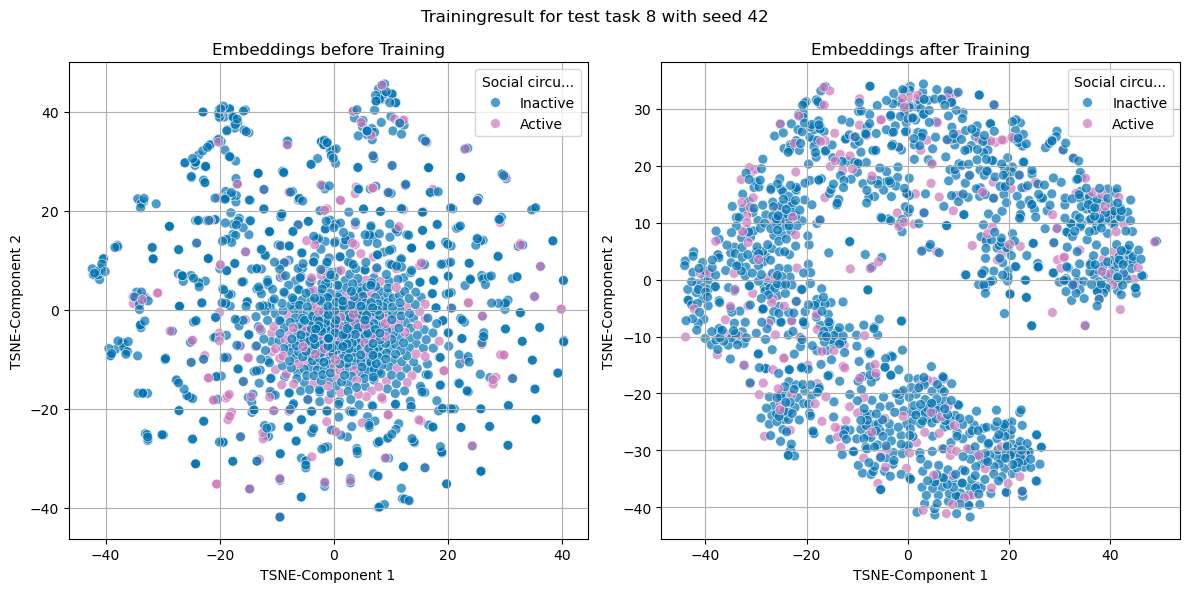

In [24]:
task_name = dataset.columns[random_task_id]
plot_labels = dataset.iloc[:,random_task_id].values[mask]
encoded_embeds = embeds.cpu().numpy()

plot_tsne_embeddings(data[mask], encoded_embeds, plot_labels, task_name, 
                     f'Trainingresult for test task {random_task_id} with seed {seed}',seed,save=True)

# 6 Evalutation over 10 seeds 

### 6.1 Average Results

In [25]:
avgResults = pd.read_csv("results/reportAvgResults.csv")
avgResults.iloc[:,1:] = round(avgResults.iloc[:,1:] * 100, 2)
avgResults

,Model,Accuracy,F1 Score,AUC,D-AUC PR
0,fst,70.28,66.42,80.53,19.19
1,fst-wle,74.98,66.79,79.44,17.86
2,fst-wwu,69.97,64.82,80.09,18.57
3,fs-baseline,68.34,64.94,77.97,17.79
4,rf-baseline,55.30,53.38,55.11,1.65


### 6.2 Mean and Std

In [26]:
# Define the folder containing the CSV files
folder_path = "results/resultsSeeds"

meanStdSeeds(folder_path)

,model,auc std (%),auc avg (%),daucPr std (%),daucPr avg (%)
0,fst,1.79,80.53,2.93,19.19
1,fst_wle,2.22,79.44,2.40,17.86
2,fst_wwu,1.98,80.09,2.65,18.57
3,fs_baseline,2.99,77.97,3.29,17.79
4,rf_baseline,0.97,55.11,0.59,1.65


### 6.3 Wilcoxon Test

In [27]:
# choose model A and B to compare
fstSeedPath  = "results/resultsSeeds/fst_results.csv"
fsSeedPath = "results/resultsSeeds/fs_baseline_results.csv"

wilcoxonComparison(fstSeedPath,fsSeedPath)

,Metric,Wilcoxon Stat,P-value
0,D-AUC PR,10.0,0.083984
1,AUC,2.0,0.005859


# 7. Notes

_... Here could be notes / open todo's_